### Load Data

In [1]:
import random
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt



def generate_data(n, r=0, inv1=False, inv2=False):
    x1 = []
    x2 = []
    y = []
    values = list(range(-int((n**0.5)//2), int((n**0.5)//2)))
    for i in values:
        for j in values:
            x1.append(i)
            x2.append(j)
            m1 = -1 if inv1 else 1
            m2 = -1 if inv2 else 1
            c = 0
            noise = random.randint(-r, r)
            y.append(c + m1*i + m2*j + noise)
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(x1, x2, y)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_zlabel("y")
    plt.show()
    return np.array(x1), np.array(x2), np.array(y)

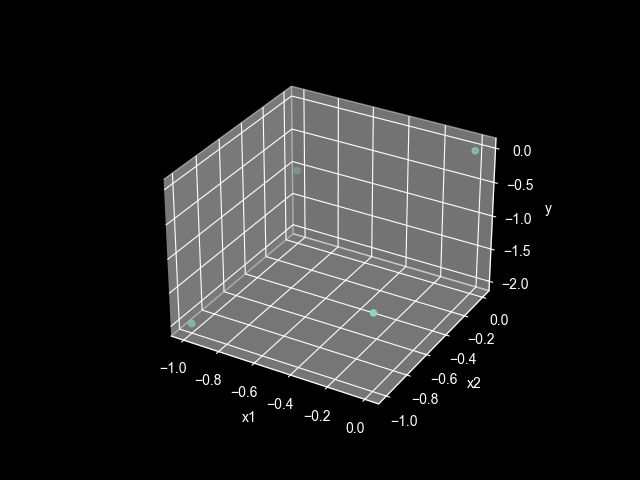

In [2]:
# Data 1
n = 10
r = 0
x11, x12, y1 = generate_data(n, r)

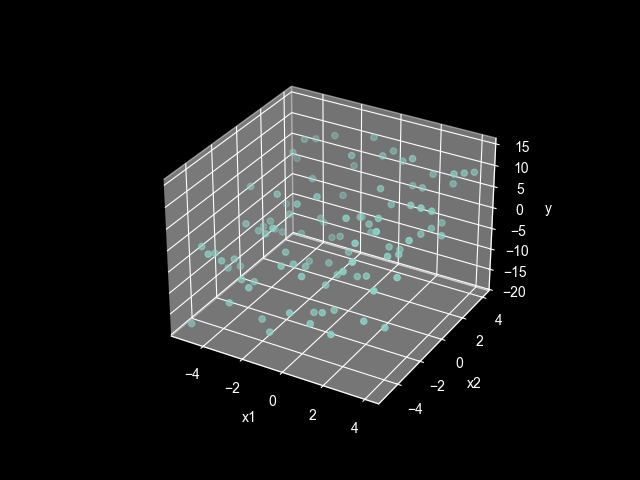

In [3]:
# Data 2
n = 100
r = 10
x21, x22, y2 = generate_data(n, r)

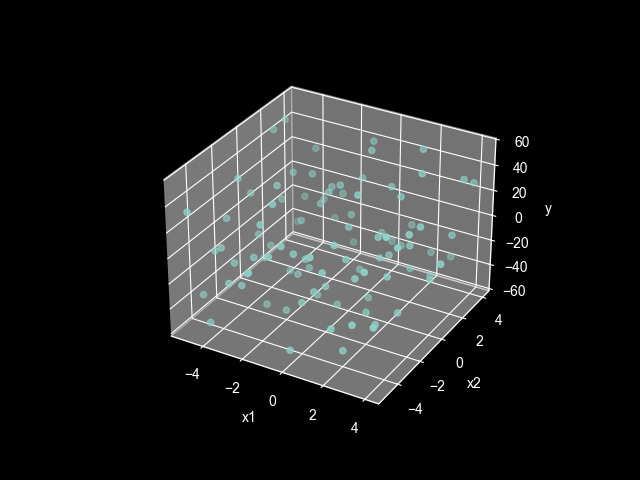

In [4]:
# Data 3
n = 100
r = 50
x31, x32, y3 = generate_data(n, r)

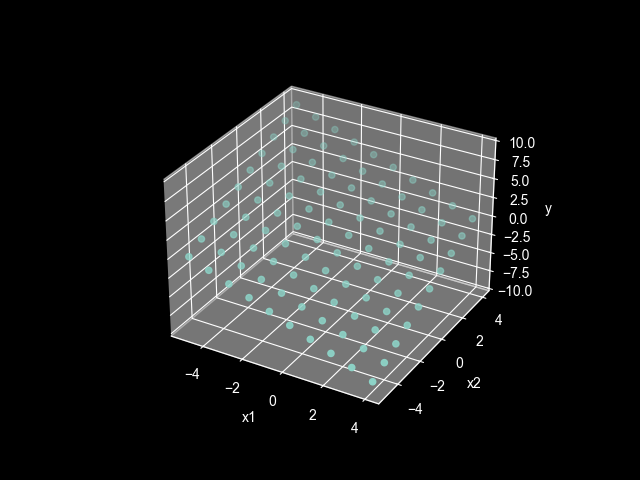

In [5]:
# Data 4
n = 100
r = 0
x41, x42, y4 = generate_data(n, r, inv1=True)

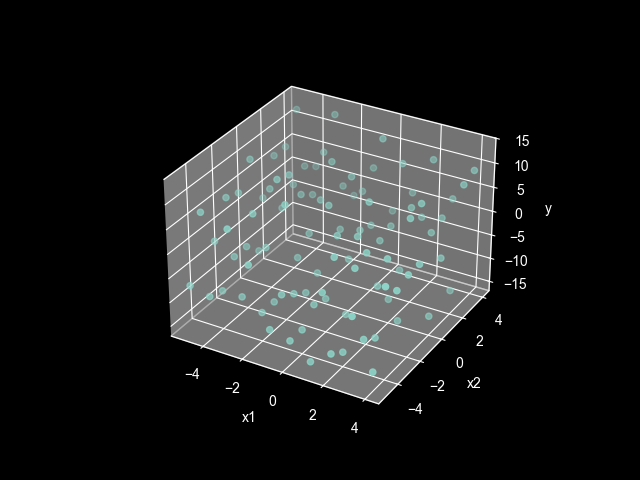

In [6]:
# Data 5
n = 100
r = 10
x51, x52, y5 = generate_data(n, r, inv1=True)

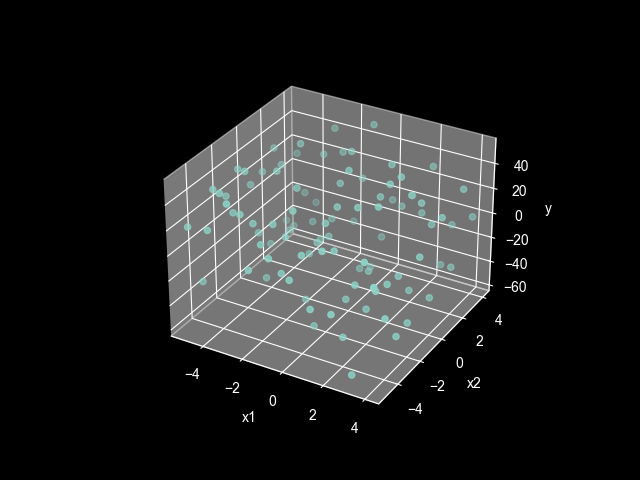

In [7]:
# Data 6
n = 100
r = 50
x61, x62, y6 = generate_data(n, r, inv1=True)

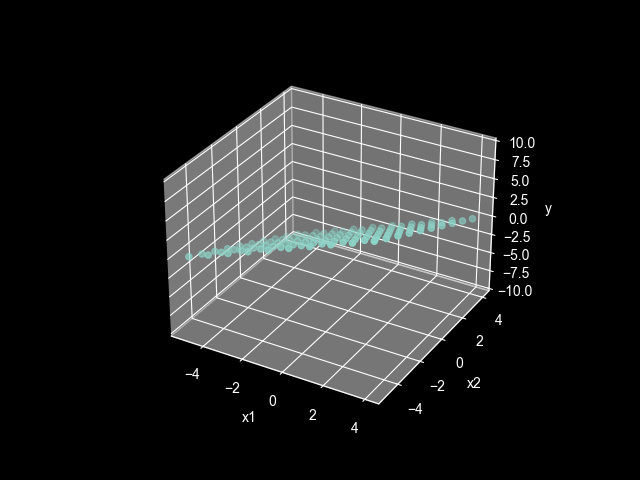

In [8]:
# Data 7
n = 100
r = 0
x71, x72, y7 = generate_data(n, r, inv2=True)

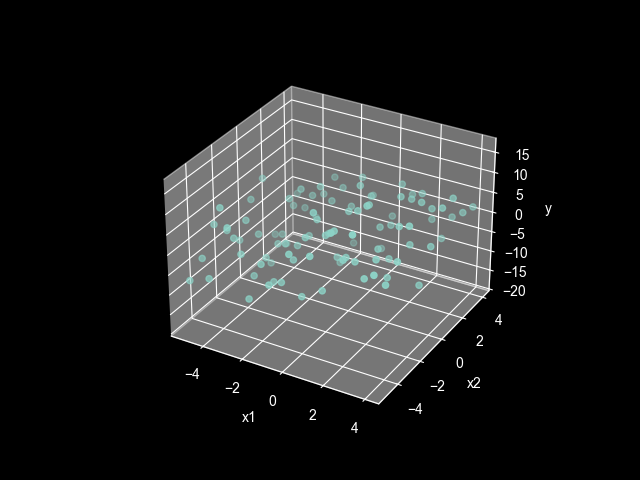

In [9]:
# Data 8
n = 100
r = 10
x81, x82, y8 = generate_data(n, r, inv2=True)

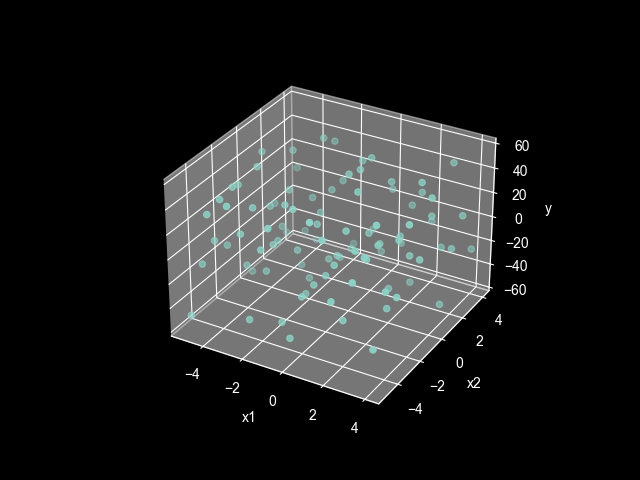

In [10]:
# Data 9
n = 100
r = 50
x91, x92, y9 = generate_data(n, r, inv2=True)

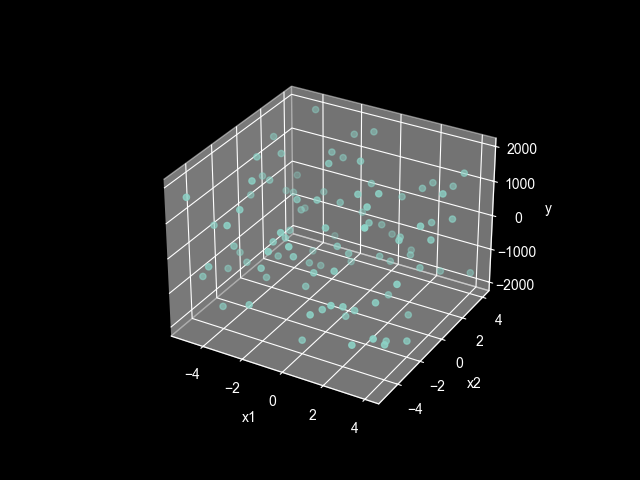

In [11]:
# Data 10
n = 100
r = 2000
x101, x102, y10 = generate_data(n, r)

### Metrics

In [12]:
def predict(X, M, c):
    return X@np.array(M).T + c

In [13]:
def mse(y, y_pred):
    n = len(y)
    sse = 0
    error = y_pred - y
    se = error**2
    sse = sum(se)
    mse = sse/n
    return mse

In [14]:
def r2(y, y_pred):
    y_mean = np.mean(y)
    return 1 - sum((y-y_pred)**2)/sum((y-y_mean)**2)


### Solve by Normal Equation

In [15]:
def solve_by_norm_eq(x1, x2, y):
    %matplotlib widget
    x_b = np.array([[1, i, j] for i, j in zip(x1, x2)])
    c, *M = np.linalg.inv(x_b.T @ x_b) @ x_b.T @ y
    y_pred = predict(np.array([x1, x2]).T, M, c)
    MSE = mse(y, y_pred)
    R2 = r2(y, y_pred)
    print(f"Slope x1 :", M[0], "  Slope X2 :", M[1],   "  y-Intercept :", round(c, 4), "  MSE :", MSE, "  R2 :", R2)
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(x1, x2, y, label="Data")
    x1_plane = np.linspace(min(x1), max(x1), 20)
    x2_plane = np.linspace(min(x2), max(x2), 20)
    X1, X2 = np.meshgrid(x1_plane, x2_plane)
    Y_plane = M[0] * X1 + M[1] * X2 + c
    ax.plot_surface(X1, X2, Y_plane, alpha=0.5)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_zlabel("y")
    plt.show()

Slope x1 : 1.0   Slope X2 : 1.0   y-Intercept : 0.0   MSE : 0.0   R2 : 1.0


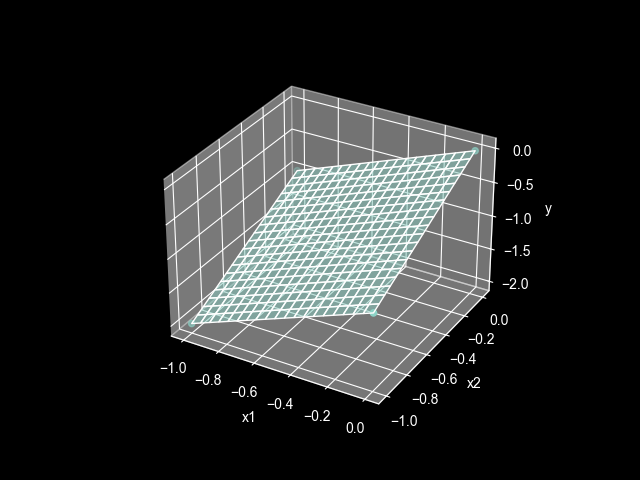

In [16]:
# Solve for Data 1
solve_by_norm_eq(x11, x12, y1)

Slope x1 : 1.0412121212121215   Slope X2 : 1.1042424242424242   y-Intercept : 0.0527   MSE : 39.61593939393939   R2 : 0.324186118739476


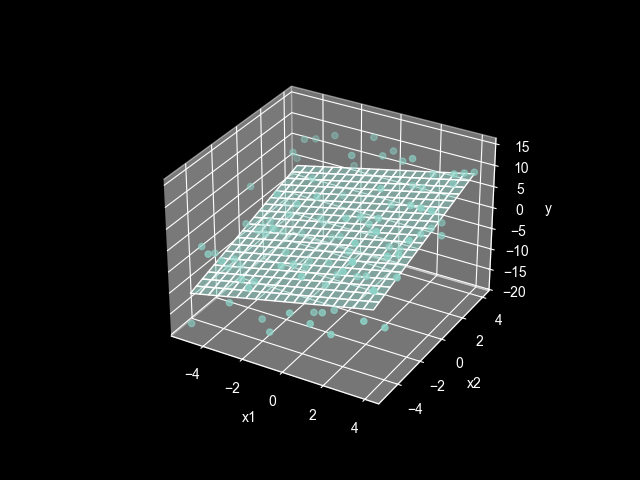

In [17]:
# Solve for Data 2
solve_by_norm_eq(x21, x22, y2)

Slope x1 : 0.8036363636363635   Slope X2 : 0.3806060606060603   y-Intercept : -3.5479   MSE : 886.8771878787878   R2 : 0.007301554959246226


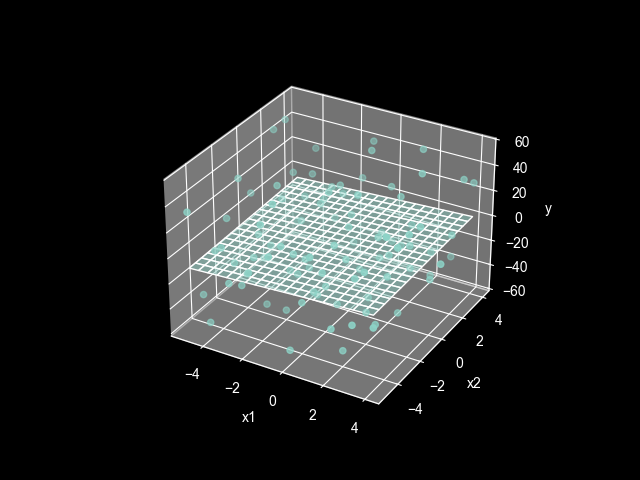

In [18]:
# Solve for Data 3
solve_by_norm_eq(x31, x32, y3)

Slope x1 : -1.0   Slope X2 : 1.0   y-Intercept : -0.0   MSE : 1.1416912710327534e-32   R2 : 1.0


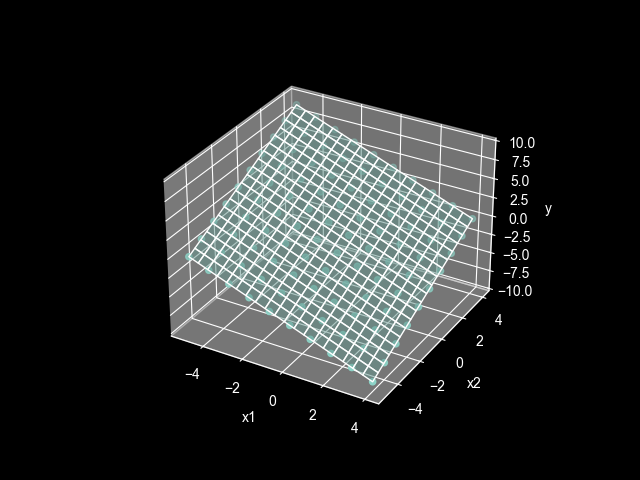

In [19]:
# Solve for Data 4
solve_by_norm_eq(x41, x42, y4)

Slope x1 : -0.5654545454545454   Slope X2 : 1.29030303030303   y-Intercept : -0.9876   MSE : 33.69437878787881   R2 : 0.32702094596537057


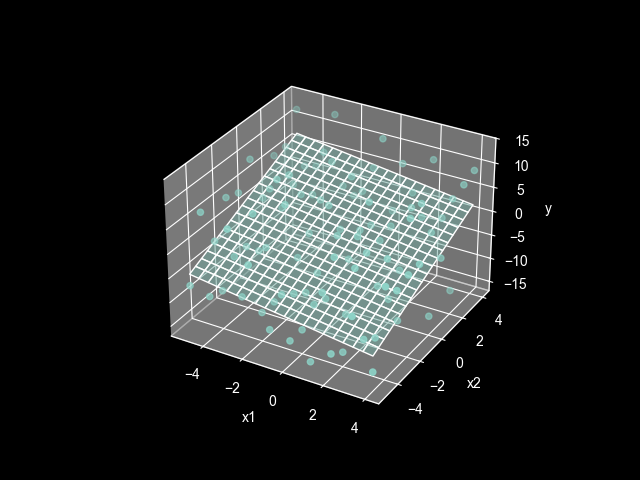

In [20]:
# Solve for Data 5
solve_by_norm_eq(x51, x52, y5)

Slope x1 : -2.1721212121212123   Slope X2 : 0.16363636363636366   y-Intercept : 3.2158   MSE : 784.4062787878788   R2 : 0.04753232367239746


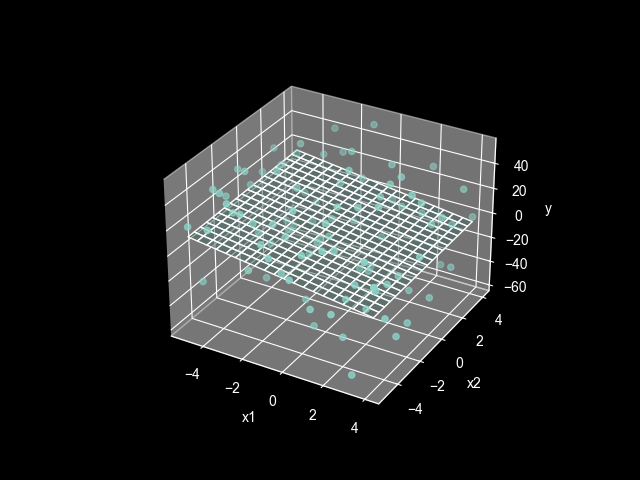

In [21]:
# Solve for Data 6
solve_by_norm_eq(x61, x62, y6)

Slope x1 : 1.0   Slope X2 : -1.0   y-Intercept : 0.0   MSE : 1.1416912710327534e-32   R2 : 1.0


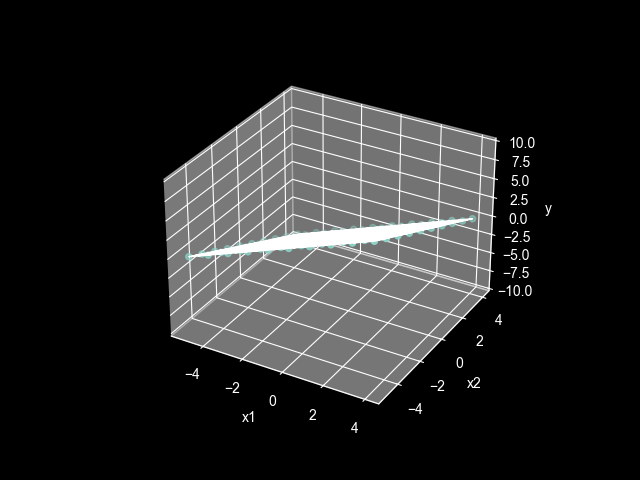

In [22]:
# Solve for Data 7
solve_by_norm_eq(x71, x72, y7)

Slope x1 : 1.1981818181818182   Slope X2 : -0.6309090909090909   y-Intercept : 0.7136   MSE : 31.757190909090912   R2 : 0.3226592049693634


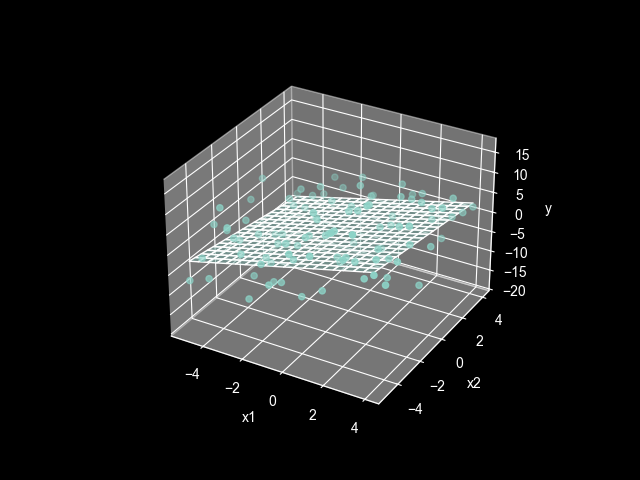

In [23]:
# Solve for Data 8
solve_by_norm_eq(x81, x82, y8)

Slope x1 : 1.0363636363636364   Slope X2 : -1.6084848484848486   y-Intercept : 2.2739   MSE : 933.3408969696972   R2 : 0.031348259959564806


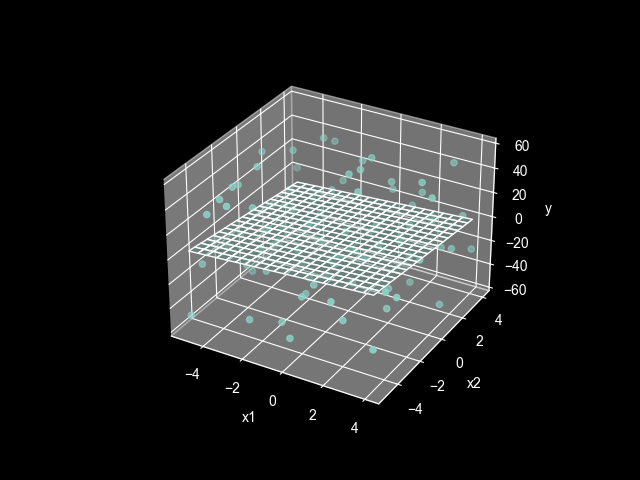

In [24]:
# Solve for Data 9
solve_by_norm_eq(x91, x92, y9)

Slope x1 : -38.352121212121205   Slope X2 : 19.966666666666676   y-Intercept : 10.8373   MSE : 1258472.3170212118   R2 : 0.012107590035370874


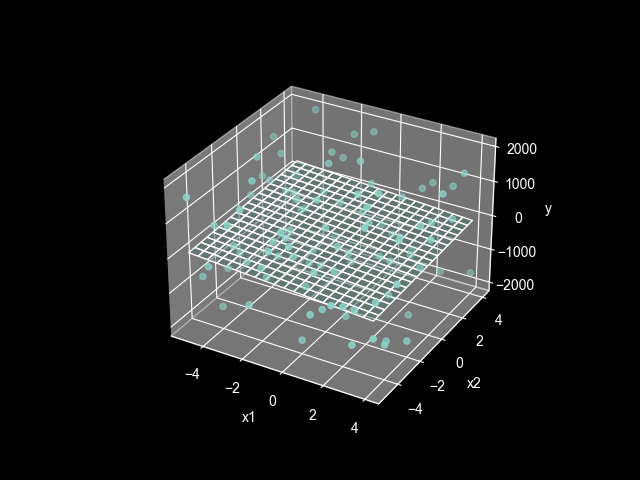

In [25]:
# Solve for Data 10
solve_by_norm_eq(x101, x102, y10)

### Solve by Gradient Descent

In [26]:
def solve_by_grad_descent(x1, x2, y, n_epochs=300, eta=0.1):
    %matplotlib widget
    x1_scaled = (x1-x1.mean())/x1.std()
    x2_scaled = (x2-x2.mean())/x2.std()
    y_scaled = (y-y.mean())/y.std()
    x_b = np.array([[1, i, j] for i, j in zip(x1_scaled, x2_scaled)])
    theta = np.array([0, 0, 0]).reshape(-1, 1)
    m = len(x_b)
    y_scaled = y_scaled.reshape(-1, 1)
    for epoch in range(n_epochs):
        gradients = 2 / m * x_b.T @ (x_b @ theta - y_scaled)
        theta = theta - eta * gradients
    m1 = theta[1][0] * y.std() / x1.std()
    m2 = theta[2][0] * y.std() / x2.std()

    c = (theta[0][0] * y.std() + y.mean() - m1 * x1.mean() - m2 * x2.mean())
    M = np.array([m1, m2])
    y_pred = predict(np.array([x1, x2]).T, M, c)
    MSE = mse(y, y_pred)
    R2 = r2(y, y_pred)
    print(f"Slope x1 :", round(M[0], 4), "  Slope X2 :", round(M[1], 4),   "  y-Intercept :", round(c, 4), "  MSE :", MSE, "  R2 :", R2)
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(x1, x2, y, label="Data")
    x1_plane = np.linspace(min(x1), max(x1), 20)
    x2_plane = np.linspace(min(x2), max(x2), 20)
    X1, X2 = np.meshgrid(x1_plane, x2_plane)
    Y_plane = M[0] * X1 + M[1] * X2 + c
    ax.plot_surface(X1, X2, Y_plane, alpha=0.5)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_zlabel("y")
    plt.show()

Slope x1 : 1.0   Slope X2 : 1.0   y-Intercept : -0.0   MSE : 5.007417855406813e-32   R2 : 1.0


C:\Users\PRASHANTH N\AppData\Local\Temp\ipykernel_26436\1137500897.py:22: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure()


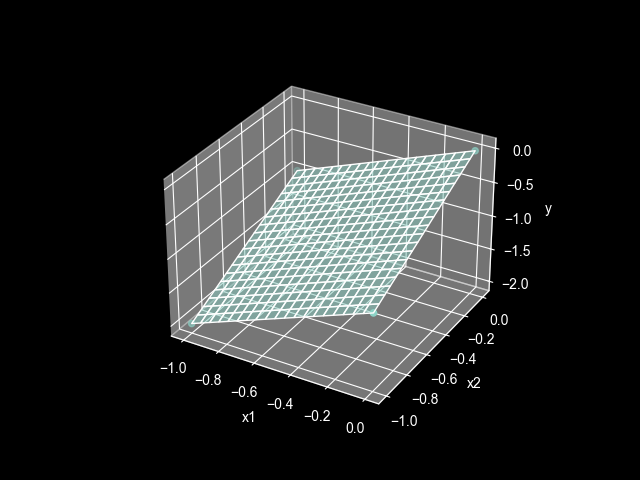

In [27]:
# Solve for Data 1
solve_by_grad_descent(x11, x12, y1)

Slope x1 : 1.0412   Slope X2 : 1.1042   y-Intercept : 0.0527   MSE : 39.615939393939385   R2 : 0.3241861187394762


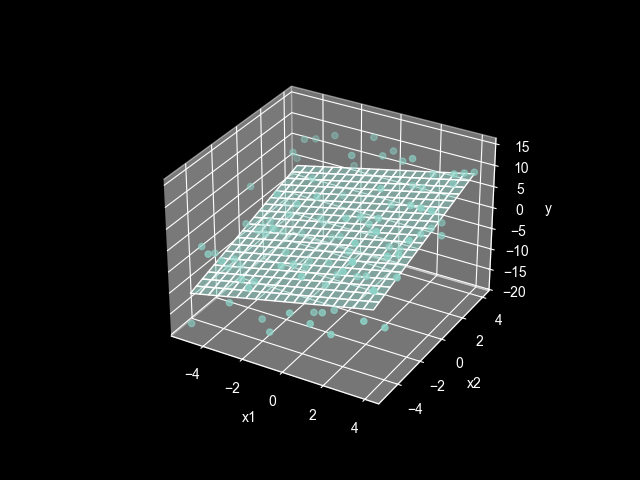

In [28]:
# Solve for Data 2
solve_by_grad_descent(x21, x22, y2)

Slope x1 : 0.8036   Slope X2 : 0.3806   y-Intercept : -3.5479   MSE : 886.8771878787878   R2 : 0.007301554959246226


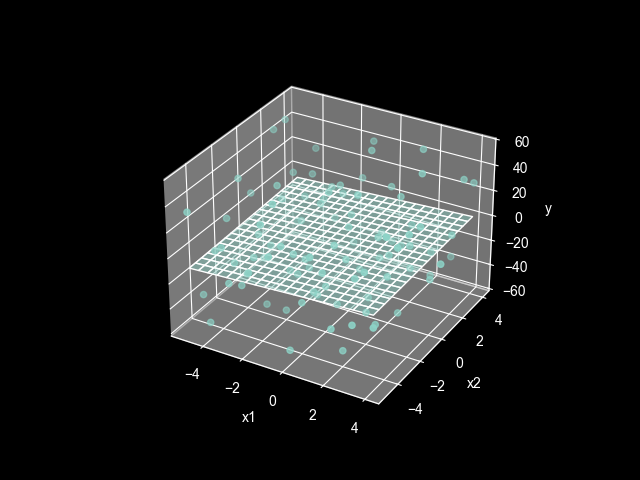

In [29]:
# Solve for Data 3
solve_by_grad_descent(x31, x32, y3)

Slope x1 : -1.0   Slope X2 : 1.0   y-Intercept : 0.0   MSE : 1.869600345373798e-30   R2 : 1.0


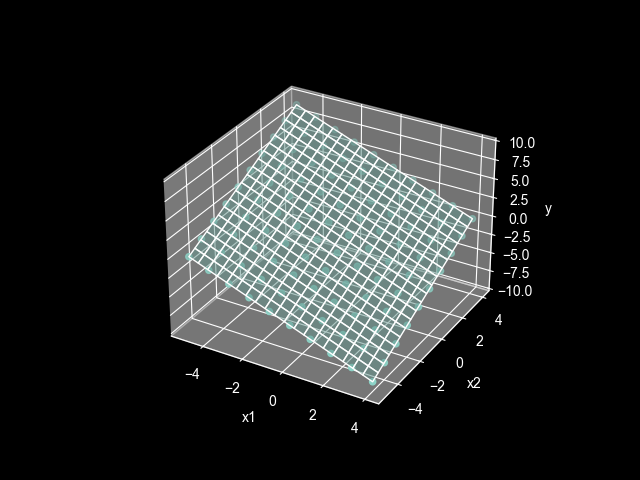

In [30]:
# Solve for Data 4
solve_by_grad_descent(x41, x42, y4)

Slope x1 : -0.5655   Slope X2 : 1.2903   y-Intercept : -0.9876   MSE : 33.69437878787881   R2 : 0.32702094596537057


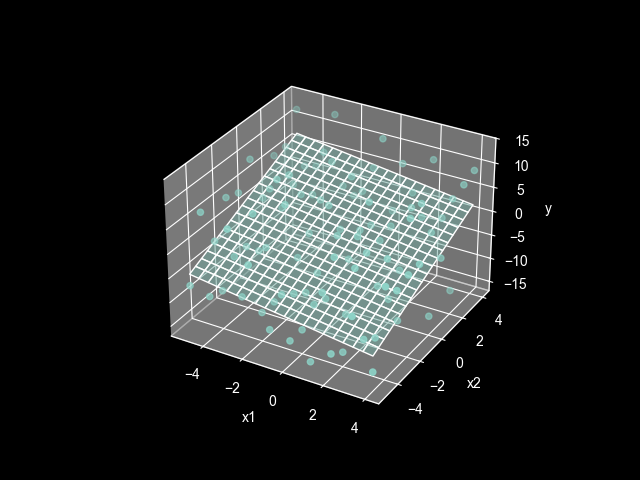

In [31]:
# Solve for Data 5
solve_by_grad_descent(x51, x52, y5)

Slope x1 : -2.1721   Slope X2 : 0.1636   y-Intercept : 3.2158   MSE : 784.4062787878788   R2 : 0.04753232367239746


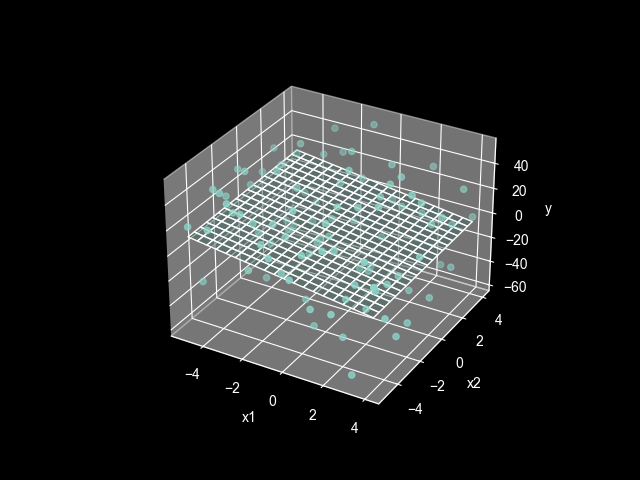

In [32]:
# Solve for Data 6
solve_by_grad_descent(x61, x62, y6)

Slope x1 : 1.0   Slope X2 : -1.0   y-Intercept : 0.0   MSE : 1.869600345373798e-30   R2 : 1.0


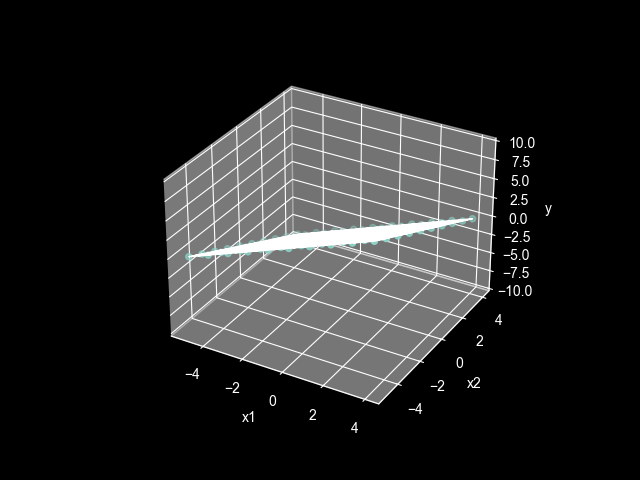

In [33]:
# Solve for Data 7
solve_by_grad_descent(x71, x72, y7)

Slope x1 : 1.1982   Slope X2 : -0.6309   y-Intercept : 0.7136   MSE : 31.757190909090912   R2 : 0.3226592049693634


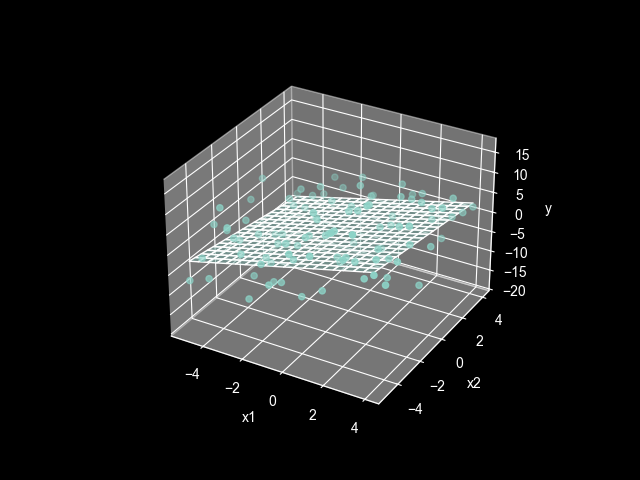

In [34]:
# Solve for Data 8
solve_by_grad_descent(x81, x82, y8)

Slope x1 : 1.0364   Slope X2 : -1.6085   y-Intercept : 2.2739   MSE : 933.3408969696972   R2 : 0.031348259959564806


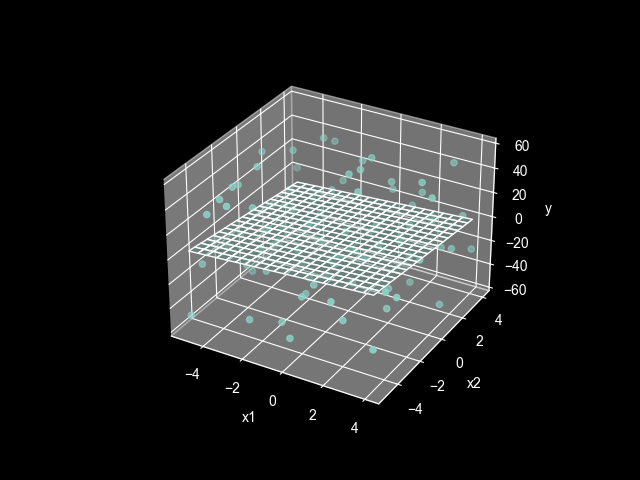

In [35]:
# Solve for Data 9
solve_by_grad_descent(x91, x92, y9)

Slope x1 : -38.3521   Slope X2 : 19.9667   y-Intercept : 10.8373   MSE : 1258472.3170212118   R2 : 0.012107590035370874


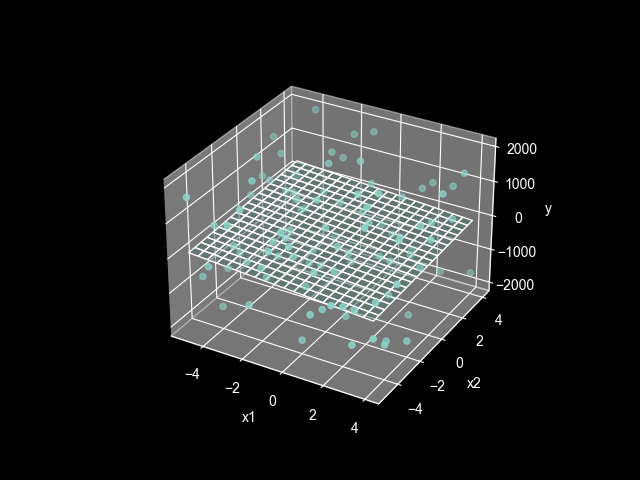

In [36]:
# Solve for Data 10
solve_by_grad_descent(x101, x102, y10)

### Solve by SkLearn

In [37]:
from sklearn.linear_model import LinearRegression

def get_model(X, y):
    model = LinearRegression()
    model.fit(X, y)
    return model.intercept_, model.coef_, model

In [38]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import add_dummy_feature

def solve_by_sklearn(x1, x2, y):
    %matplotlib widget
    X = np.array([x1, x2]).T
    c, m, model = get_model(X, y)
    y_pred = model.predict(X)
    MSE = mean_squared_error(y, y_pred)
    R2 = r2_score(y, y_pred)
    print(f"Slope x1 :", round(m[0], 4), "  Slope X2 :", round(m[1], 4),   "  y-Intercept :", round(c, 4), "  MSE :", MSE, "  R2 :", R2)
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(x1, x2, y, label="Data")
    x1_plane = np.linspace(min(x1), max(x1), 20)
    x2_plane = np.linspace(min(x2), max(x2), 20)
    X1, X2 = np.meshgrid(x1_plane, x2_plane)
    Y_plane = m[0] * X1 + m[1] * X2 + c
    ax.plot_surface(X1, X2, Y_plane, alpha=0.5)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_zlabel("y")
    plt.show()



Slope x1 : 1.0   Slope X2 : 1.0   y-Intercept : 0.0   MSE : 3.0814879110195774e-33   R2 : 1.0


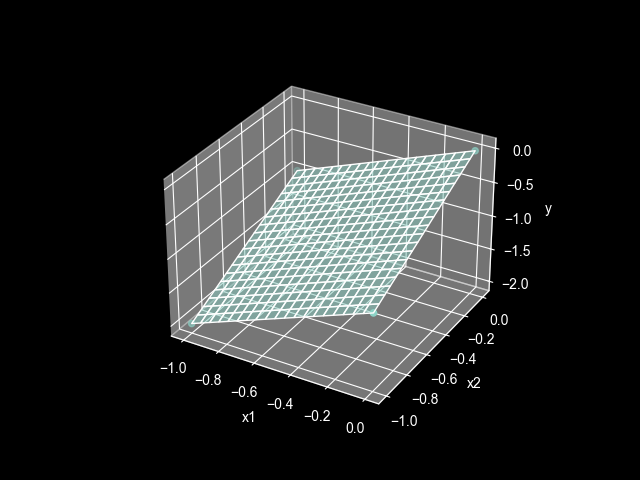

In [39]:
# Solve for Data 1
solve_by_sklearn(x11, x12, y1)

Slope x1 : 1.0412   Slope X2 : 1.1042   y-Intercept : 0.0527   MSE : 39.61593939393939   R2 : 0.32418611873947645


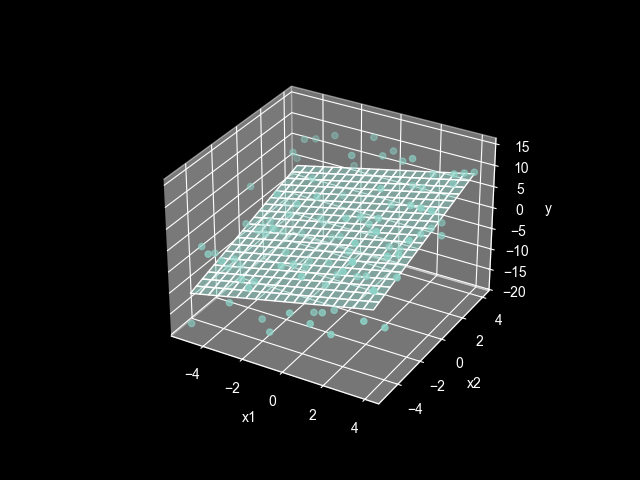

In [40]:
# Solve for Data 2
solve_by_sklearn(x21, x22, y2)

Slope x1 : 0.8036   Slope X2 : 0.3806   y-Intercept : -3.5479   MSE : 886.8771878787879   R2 : 0.007301554959245782


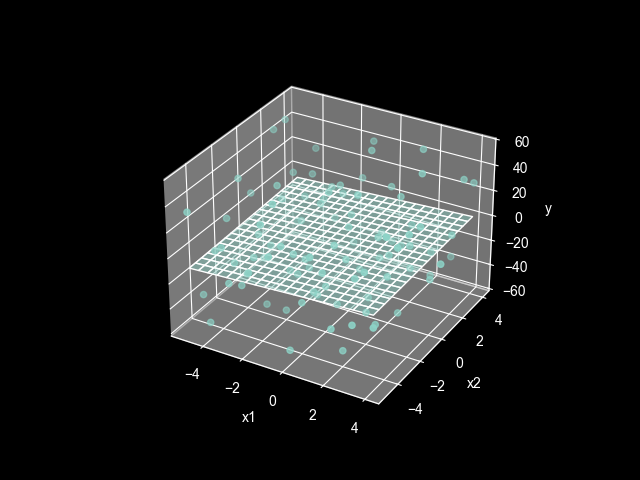

In [41]:
# Solve for Data 3
solve_by_sklearn(x31, x32, y3)

Slope x1 : -1.0   Slope X2 : 1.0   y-Intercept : 0.0   MSE : 0.0   R2 : 1.0


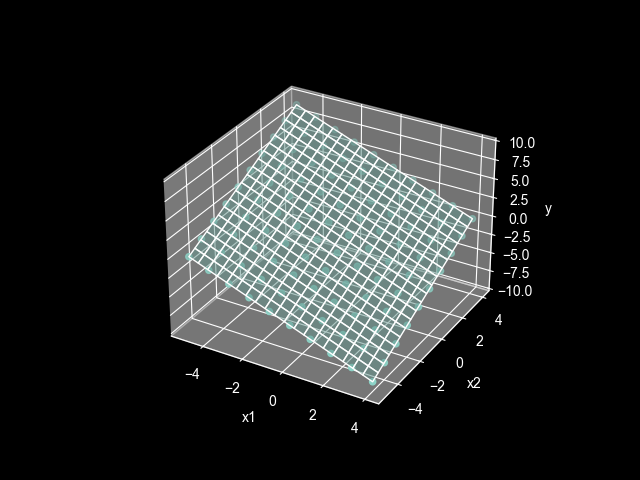

In [42]:
# Solve for Data 4
solve_by_sklearn(x41, x42, y4)

Slope x1 : -0.5655   Slope X2 : 1.2903   y-Intercept : -0.9876   MSE : 33.6943787878788   R2 : 0.3270209459653707


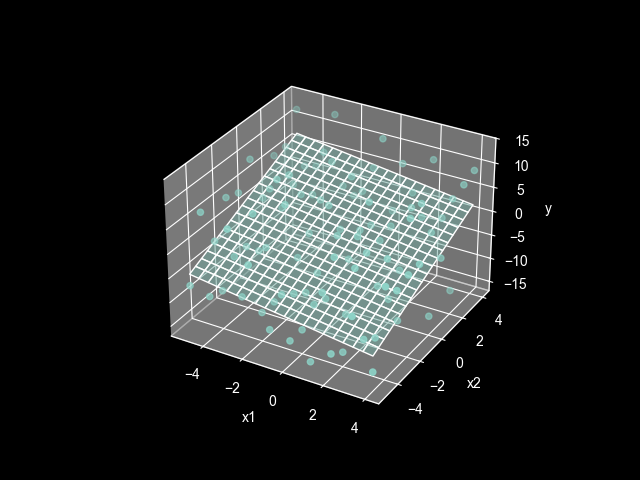

In [43]:
# Solve for Data 5
solve_by_sklearn(x51, x52, y5)

Slope x1 : -2.1721   Slope X2 : 0.1636   y-Intercept : 3.2158   MSE : 784.4062787878788   R2 : 0.04753232367239779


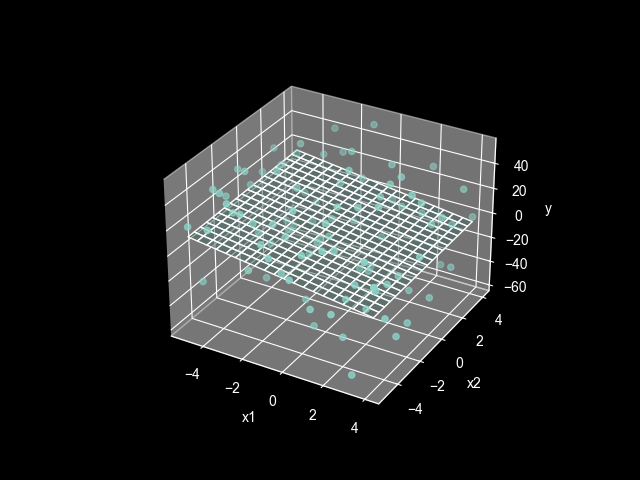

In [44]:
# Solve for Data 6
solve_by_sklearn(x61, x62, y6)

Slope x1 : 1.0   Slope X2 : -1.0   y-Intercept : 0.0   MSE : 0.0   R2 : 1.0


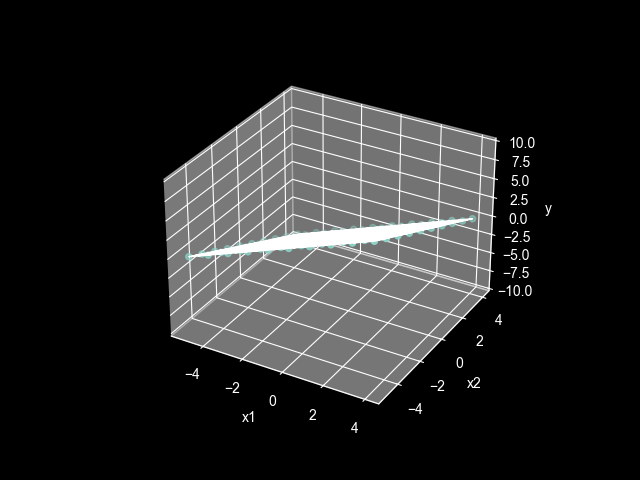

In [45]:
# Solve for Data 7
solve_by_sklearn(x71, x72, y7)

Slope x1 : 1.1982   Slope X2 : -0.6309   y-Intercept : 0.7136   MSE : 31.75719090909091   R2 : 0.3226592049693632


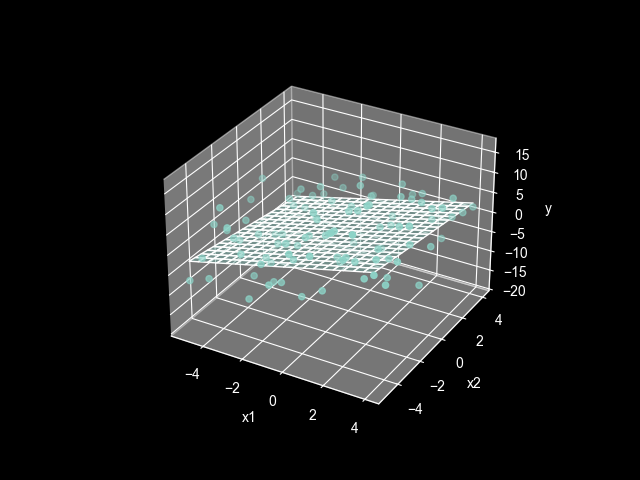

In [46]:
# Solve for Data 8
solve_by_sklearn(x81, x82, y8)

Slope x1 : 1.0364   Slope X2 : -1.6085   y-Intercept : 2.2739   MSE : 933.3408969696969   R2 : 0.03134825995956536


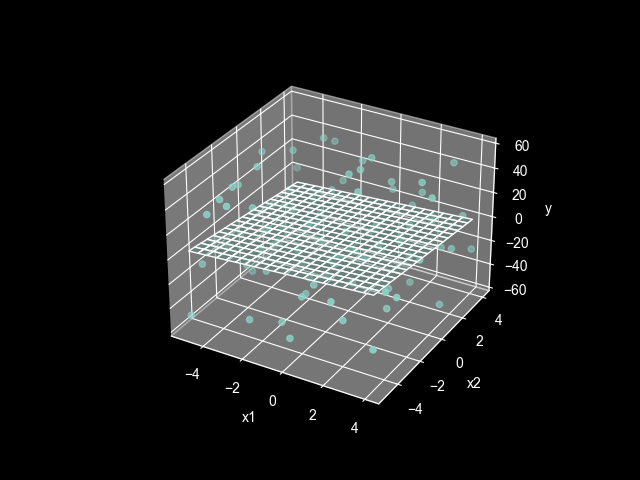

In [47]:
# Solve for Data 9
solve_by_sklearn(x91, x92, y9)

Slope x1 : -38.3521   Slope X2 : 19.9667   y-Intercept : 10.8373   MSE : 1258472.317021212   R2 : 0.01210759003537032


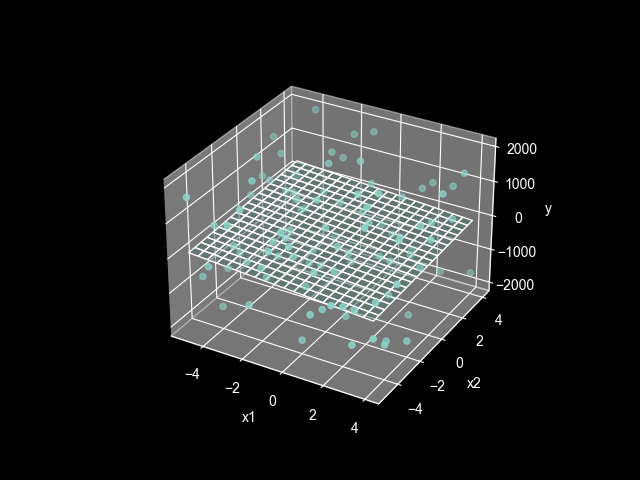

In [48]:
# Solve for Data 10
solve_by_sklearn(x101, x102, y10)